In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import datetime
import unicodedata

# Configuração inteligente: Tenta usar o display do Notebook. Se não conseguir (ex: PyCharm), usa o print
try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

In [ ]:
# Estrutura padrão do projeto
RAIZ = Path(".")
PASTAS = [
    "dados_brutos", "dados_tratados",
    "notebooks", "sql", "dashboards", "relatorios", "apresentacao", "logs"
]

for pasta in PASTAS:
    (RAIZ / pasta).mkdir(parents=True, exist_ok=True)

print("Pastas verificadas/criadas:")
for pasta in PASTAS:
    print("-", RAIZ / pasta)

ARQUIVO_BRUTO = Path("dados_brutos/acidentes2025.csv")
ARQUIVO_BASE_ANALITICA = Path("dados_tratados/base_analitica_prf_2025.csv")
ARQUIVO_BASE_MODELAVEL = Path("dados_tratados/base_modelavel_prf_2025.csv")
ARQUIVO_DICIONARIO = Path("dados_tratados/dicionario_variaveis_modulo4.csv")
ARQUIVO_DECISOES = Path("logs/decisoes_tratamento_modulo4.md")
ARQUIVO_README = Path("README.md")

SEPARADOR = ";"
ENCODING_ENTRADA = "latin1"
ENCODING_SAIDA = "utf-8-sig"

Pastas verificadas/criadas:
- dados_brutos
- dados_tratados
- notebooks
- sql
- dashboards
- relatorios
- apresentacao
- logs


In [ ]:
def ler_csv_prf(caminho, sep=";", encodings=("latin1", "utf-8", "utf-8-sig")):
    ultimo_erro = None
    for enc in encodings:
        try:
            print(f"Tentando encoding={enc}...")
            return pd.read_csv(caminho, sep=sep, encoding=enc, low_memory=False)
        except Exception as erro:
            ultimo_erro = erro
            print(f"Falhou com {enc}: {erro}")

    # Se testou todos os encodings e todos falharam, levanta o último erro
    raise ultimo_erro

# Lê o arquivo e exibe as 5 primeiras linhas
# Lê o arquivo e exibe as 5 primeiras linhas
df = ler_csv_prf(ARQUIVO_BRUTO, sep=SEPARADOR)

# Etapa 10: Retrato inicial da base
print("Dimensões:", df.shape)
print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])
display(df.head())
display(df.sample(5, random_state=42))

Tentando encoding=latin1...
Dimensões: (72529, 30)
Linhas: 72529
Colunas: 30


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,652493,01/01/2025,quarta-feira,06:20:00,SP,116,225,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Múltipla,Reta;Declive,Sim,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP
1,652519,01/01/2025,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,NaN,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,6,1,1,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE
2,652522,01/01/2025,quarta-feira,08:45:00,PR,369,"88,2",CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Dupla,Reta;Aclive,Sim,5,0,3,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR
3,652544,01/01/2025,quarta-feira,11:00:00,PR,116,74,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Dupla,Reta,Não,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
4,652549,01/01/2025,quarta-feira,09:30:00,MG,251,471,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Curva;Declive,Não,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
6366,691804,15/03/2025,sábado,12:30:00,ES,101,67,SAO MATEUS,Condutor desrespeitou a iluminação vermelha do...,Colisão transversal,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Simples,Rotatória,Sim,4,0,0,2,1,2,2,4,"-18,72802869","-39,85997558",SPRF-ES,DEL04-ES,UOP02-DEL04-ES
9405,704622,13/07/2025,domingo,22:30:00,PE,423,"74,1",JUPI,Condutor deixou de manter distância do veículo...,Colisão traseira,Sem Vítimas,Plena Noite,Decrescente,Céu Claro,Simples,Aclive;Reta,Sim,2,0,0,0,2,0,0,2,"-8,7160879","-36,4219923",SPRF-PE,DEL03-PE,UOP01-DEL03-PE
26102,663260,23/02/2025,domingo,18:10:00,BA,242,231,ITABERABA,Animais na Pista,Atropelamento de Animal,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Simples,Reta,Sim,1,0,1,0,0,0,1,1,"-12,511706","-40,324247",SPRF-BA,DEL06-BA,UOP02-DEL06-BA
28616,667036,13/03/2025,quinta-feira,19:55:00,DF,20,"9,9",BRASILIA,Reação tardia ou ineficiente do condutor,Engavetamento,Com Vítimas Feridas,Plena Noite,Crescente,Céu Claro,Dupla,Reta,Não,6,0,4,0,2,0,4,3,"-15,6502715","-47,7763723",SPRF-DF,DEL02-DF,UOP01-DEL02-DF
1696,660353,09/02/2025,domingo,19:05:00,MA,222,665,ACAILANDIA,Pedestre andava na pista,Atropelamento de Pedestre,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Simples,Declive,Não,3,0,1,1,0,1,2,3,"-4,89367779","-47,38426513",SPRF-MA,DEL04-MA,UOP03-DEL04-MA


In [ ]:
def normalizar_nome_coluna(nome):
    # 1. Transforma em string, remove espaços nas pontas e deixa minúsculo
    nome = str(nome).strip().lower()
    # 2. Remove os acentos da string
    nome = unicodedata.normalize("NFKD", nome).encode("ascii", "ignore").decode("utf-8")
    # 3. Troca espaços, hifens e barras por underline (_)
    nome = nome.replace(" ", "_").replace("-", "_").replace("/", "_")
    # 4. Garante que não sobrou nenhum espaço (embora o replace acima já faça isso)
    while " " in nome:
        nome = nome.replace(" ", "_")
    # 5. Retorna o nome tirando qualquer underline que tenha ficado sobrando no começo ou no fim
    return nome.strip("_")

# Aplica a função de limpeza em todas as colunas do seu DataFrame (df)
df.columns = [normalizar_nome_coluna(c) for c in df.columns]

# Dicionário de colunas específicas para renomear
renomear = {
    "condicao_meteorologica": "condicao_metereologica"
}

# Aplica o dicionário, mas apenas se a chave (k) existir de fato no seu df
df = df.rename(columns={k: v for k, v in renomear.items() if k in df.columns})

# Lista de colunas que esperamos encontrar na base de dados
colunas_esperadas = [
    "data_inversa", "dia_semana", "horario", "uf", "br",
    "municipio", "causa_acidente", "tipo_acidente",
    "classificacao_acidente", "fase_dia", "condicao_metereologica",
    "tipo_pista", "tracado_via", "uso_solo", "pessoas",
    "mortos", "feridos_leves", "feridos_graves", "feridos", "veiculos"
]

# Verifica quais colunas da lista acima NÃO estão no DataFrame
faltantes = [c for c in colunas_esperadas if c not in df.columns]
print("Colunas faltantes:", faltantes)

# Se a lista de faltantes não estiver vazia, exibe o aviso
if faltantes:
    print("Atenção: ajuste nomes ou confirme o dicionário da PRF.")

Colunas faltantes: []


In [ ]:
# Tipos de dados e memória utilizada
df.info(memory_usage="deep")

# Agrupa e conta a quantidade de colunas para cada tipo de dado
resumo_tipos = (
    df.dtypes.astype(str)
    .value_counts()
    .rename_axis("tipo")
    .reset_index(name="qtd_colunas")
)
display(resumo_tipos)

# Diagnóstico de valores ausentes
nulos = pd.DataFrame({
    "qtd_nulos": df.isna().sum(),
    "perc_nulos": df.isna().mean() * 100
}).sort_values("perc_nulos", ascending=False)
display(nulos[nulos["qtd_nulos"] > 0])

# Diagnóstico e remoção de duplicidades
qtd_duplicadas = df.duplicated().sum()
print("Duplicidades exatas:", qtd_duplicadas)
if qtd_duplicadas > 0:
    df = df.drop_duplicates().copy()
    print("Duplicidades removidas.")
print("Nova dimensão:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72529 entries, 0 to 72528
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      72529 non-null  int64 
 1   data_inversa            72529 non-null  object
 2   dia_semana              72529 non-null  object
 3   horario                 72529 non-null  object
 4   uf                      72529 non-null  object
 5   br                      72529 non-null  int64 
 6   km                      72529 non-null  object
 7   municipio               72529 non-null  object
 8   causa_acidente          72529 non-null  object
 9   tipo_acidente           72529 non-null  object
 10  classificacao_acidente  72528 non-null  object
 11  fase_dia                72529 non-null  object
 12  sentido_via             72529 non-null  object
 13  condicao_metereologica  72529 non-null  object
 14  tipo_pista              72529 non-null  object
 15  tr

,tipo,qtd_colunas
0,object,20
1,int64,10


,qtd_nulos,perc_nulos
uop,38,0.052393
delegacia,22,0.030333
regional,2,0.002758
classificacao_acidente,1,0.001379


Duplicidades exatas: 0
Nova dimensão: (72529, 30)


In [ ]:
# PADRONIZAÇÃO DE TEXTOS
print("Iniciando a padronização de textos...")

# Identifica todas as colunas que contêm textos
colunas_texto = df.select_dtypes(include=["object"]).columns

# Itera sobre cada coluna de texto para aplicar as regras
for coluna in colunas_texto:
    df[coluna] = df[coluna].astype(str).str.strip().str.upper()
    df[coluna] = df[coluna].replace(["", "NAN", "NONE", "NULL"], pd.NA)

print("Colunas textuais padronizadas:", len(colunas_texto))
print("Padronização de textos concluída!")

# Cardinalidade das variáveis categóricas
categoricas = df.select_dtypes(include=["object"]).columns
cardinalidade = (
    df[categoricas]
    .nunique(dropna=True)
    .sort_values(ascending=False)
    .reset_index()
)
cardinalidade.columns = ["variavel", "qtd_categorias"]
display(cardinalidade.head(30))

Iniciando a padronização de textos...
Colunas textuais padronizadas: 20
Padronização de textos concluída!


,variavel,qtd_categorias
0,latitude,69294
1,longitude,69237
2,km,7655
3,municipio,1844
4,horario,1412
5,tracado_via,605
6,uop,395
7,data_inversa,365
8,delegacia,153
9,causa_acidente,69


In [ ]:
# Lista de colunas que devem ser tratadas como números
colunas_numericas = [
    "br", "km", "pessoas", "mortos", "feridos",
    "feridos_leves", "feridos_graves", "ilesos",
    "ignorados", "veiculos"
]

# Itera sobre cada coluna da nossa lista
for coluna in colunas_numericas:
    if coluna in df.columns:
        df[coluna] = pd.to_numeric(df[coluna], errors="coerce")

# Exibe os tipos de dados apenas dessas colunas para confirmar a mudança
print(df[[c for c in colunas_numericas if c in df.columns]].dtypes)

br                  int64
km                float64
pessoas             int64
mortos              int64
feridos             int64
feridos_leves       int64
feridos_graves      int64
ilesos              int64
ignorados           int64
veiculos            int64
dtype: object


In [ ]:
# Converte a coluna de data (texto) para o formato datetime do Pandas
df["data_inversa"] = pd.to_datetime(df["data_inversa"], errors="coerce")

# Extrai informações específicas da data para criar novas colunas
df["ano"] = df["data_inversa"].dt.year
df["mes"] = df["data_inversa"].dt.month
df["trimestre"] = df["data_inversa"].dt.quarter
df["dia_semana_num"] = df["data_inversa"].dt.dayofweek
df["fim_de_semana"] = df["dia_semana_num"].isin([5, 6]).astype(int)

# Limpa a coluna de horário (converte para texto e remove espaços nas pontas)
horario_limpo = df["horario"].astype(str).str.strip()
# Converte para datetime e extrai apenas a hora (formato HH:MM:SS)[cite: 1]
df["hora"] = pd.to_datetime(horario_limpo, format="%H:%M:%S", errors="coerce").dt.hour
# Tentativa alternativa (fallback) para arquivos ou linhas que venham apenas com HH:MM[cite: 1]
faltou_hora = df["hora"].isna()
if faltou_hora.any():
    df.loc[faltou_hora, "hora"] = pd.to_datetime(
        horario_limpo[faltou_hora], format="%H:%M", errors="coerce"
    ).dt.hour

# Define e aplica a função que vai classificar a hora em um turno do dia
def classificar_turno(hora):
    if pd.isna(hora): return "IGNORADO"
    if 0 <= hora <= 5: return "MADRUGADA"
    if 6 <= hora <= 11: return "MANHA"
    if 12 <= hora <= 17: return "TARDE"
    return "NOITE"

df["turno"] = df["hora"].apply(classificar_turno)

# Define e aplica a função para criar faixas de 3 horas
def criar_faixa_horaria(hora):
    if pd.isna(hora): return "IGNORADO"
    inicio = int(hora // 3) * 3
    fim = inicio + 2
    return f"{inicio:02d}h-{fim:02d}h"

df["faixa_horaria"] = df["hora"].apply(criar_faixa_horaria)

display(df["faixa_horaria"].value_counts(dropna=False).sort_index())

,count
faixa_horaria,
00h-02h,3959
03h-05h,4948
06h-08h,11517
09h-11h,9342
12h-14h,9678
15h-17h,12624
18h-20h,13473
21h-23h,6988


In [ ]:
# Lista das colunas categóricas mais importantes para a análise
categoricas_importantes = [
    "uf", "municipio", "causa_acidente", "tipo_acidente", "fase_dia",
    "condicao_metereologica", "tipo_pista", "tracado_via", "uso_solo",
    "classificacao_acidente", "dia_semana"
]

for coluna in categoricas_importantes:
    if coluna in df.columns:
        df[coluna] = df[coluna].fillna("IGNORADO")

display(df[categoricas_importantes].isna().sum().sort_values(ascending=False))

# Lista de colunas numéricas referentes a contagens
contagens_vitimas = [
    "mortos", "feridos", "feridos_leves",
    "feridos_graves", "pessoas", "veiculos"
]

for coluna in contagens_vitimas:
    if coluna in df.columns:
        df[coluna] = df[coluna].fillna(0)

display(df[[c for c in contagens_vitimas if c in df.columns]].isna().sum())

,0
uf,0
municipio,0
causa_acidente,0
tipo_acidente,0
fase_dia,0
condicao_metereologica,0
tipo_pista,0
tracado_via,0
uso_solo,0
classificacao_acidente,0


,0
mortos,0
feridos,0
feridos_leves,0
feridos_graves,0
pessoas,0
veiculos,0


In [ ]:
# Cria a coluna alvo: 1 se o número de mortos for maior ou igual a 1, caso contrário, 0
df["acidente_fatal"] = np.where(df["mortos"] >= 1, 1, 0)

# Agrupa e conta a quantidade de cada categoria
validacao_alvo = (
    df["acidente_fatal"]
    .value_counts(dropna=False)
    .rename_axis("acidente_fatal")
    .reset_index(name="qtd")
)
validacao_alvo["perc"] = (validacao_alvo["qtd"] / validacao_alvo["qtd"].sum()) * 100
display(validacao_alvo)

# Teste lógico da variável-alvo
violacoes = df.loc[
    ((df["mortos"] >= 1) & (df["acidente_fatal"] != 1)) |
    ((df["mortos"] == 0) & (df["acidente_fatal"] != 0))
]
print("Violações da regra do alvo:", len(violacoes))
assert len(violacoes) == 0, "Há erro na criação de acidente_fatal."

,acidente_fatal,qtd,perc
0,0,67319,92.816666
1,1,5210,7.183334


Violações da regra do alvo: 0


In [ ]:
# Criação de indicadores adicionais
df["total_vitimas"] = df["mortos"] + df["feridos_leves"] + df["feridos_graves"]
df["acidente_grave"] = np.where((df["mortos"] >= 1) | (df["feridos_graves"] >= 1), 1, 0)
df["indice_gravidade"] = (df["mortos"] * 3) + (df["feridos_graves"] * 2) + df["feridos_leves"]

display(df[["mortos", "feridos_leves", "feridos_graves", "total_vitimas", "indice_gravidade"]].head())

# Formatação da rodovia (BR)
def formatar_br(valor):
    if pd.isna(valor) or valor == 0: return "BR-IGNORADA"
    return f"BR-{int(valor):03d}"

df["br_formatada"] = df["br"].apply(formatar_br)

# Chave de localidade
df["chave_localidade"] = (
    df["uf"].astype(str) + "_" +
    df["municipio"].astype(str) + "_" +
    df["br_formatada"].astype(str)
)

display(df[["uf", "municipio", "br", "br_formatada", "chave_localidade"]].head())

,mortos,feridos_leves,feridos_graves,total_vitimas,indice_gravidade
0,0,1,0,1,1
1,1,1,0,2,4
2,0,3,0,3,3
3,0,1,0,1,1
4,0,1,1,2,3


,uf,municipio,br,br_formatada,chave_localidade
0,SP,GUARULHOS,116,BR-116,SP_GUARULHOS_BR-116
1,CE,PENAFORTE,116,BR-116,CE_PENAFORTE_BR-116
2,PR,CORNELIO PROCOPIO,369,BR-369,PR_CORNELIO PROCOPIO_BR-369
3,PR,CAMPINA GRANDE DO SUL,116,BR-116,PR_CAMPINA GRANDE DO SUL_BR-116
4,MG,FRANCISCO SA,251,BR-251,MG_FRANCISCO SA_BR-251


{'linhas': 72529,
 'colunas': 44,
 'acidentes_fatais': 5210,
 'taxa_fatalidade': 0.07183333563126473,
 'total_mortos': 6043,
 'total_feridos': 83550}

--- RANKING: CAUSA DO ACIDENTE ---


,causa_acidente,qtd
0,AUSÊNCIA DE REAÇÃO DO CONDUTOR,11469
1,REAÇÃO TARDIA OU INEFICIENTE DO CONDUTOR,10799
2,ACESSAR A VIA SEM OBSERVAR A PRESENÇA DOS OUTR...,7097
3,CONDUTOR DEIXOU DE MANTER DISTÂNCIA DO VEÍCULO...,4413
4,VELOCIDADE INCOMPATÍVEL,4088
5,MANOBRA DE MUDANÇA DE FAIXA,4016
6,INGESTÃO DE ÁLCOOL PELO CONDUTOR,3685
7,DEMAIS FALHAS MECÂNICAS OU ELÉTRICAS,3385
8,TRANSITAR NA CONTRAMÃO,2475
9,CONDUTOR DORMINDO,2116



--- RANKING: TIPO DE ACIDENTE ---


,tipo_acidente,qtd
0,COLISÃO TRASEIRA,14360
1,SAÍDA DE LEITO CARROÇÁVEL,10209
2,COLISÃO TRANSVERSAL,9306
3,COLISÃO LATERAL MESMO SENTIDO,7885
4,TOMBAMENTO,6351
5,COLISÃO COM OBJETO,5109
6,COLISÃO FRONTAL,4739
7,QUEDA DE OCUPANTE DE VEÍCULO,3450
8,ATROPELAMENTO DE PEDESTRE,3057
9,COLISÃO LATERAL SENTIDO OPOSTO,2152


--- TAXA DE FATALIDADE POR TIPO DE ACIDENTE ---


,tipo_acidente,qtd_acidentes,qtd_fatais,taxa_fatal
1,ATROPELAMENTO DE PEDESTRE,3057,902,0.295061
4,COLISÃO FRONTAL,4739,1396,0.294577
6,COLISÃO LATERAL SENTIDO OPOSTO,2152,212,0.098513
11,EVENTOS ATÍPICOS,287,23,0.080139
0,ATROPELAMENTO DE ANIMAL,1133,68,0.060018
14,SAÍDA DE LEITO CARROÇÁVEL,10209,605,0.059261
3,COLISÃO COM OBJETO,5109,297,0.058133
2,CAPOTAMENTO,1373,63,0.045885
7,COLISÃO TRANSVERSAL,9306,427,0.045884
8,COLISÃO TRASEIRA,14360,619,0.043106


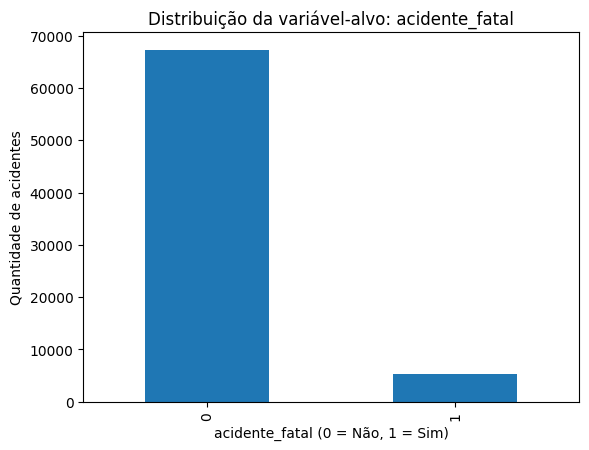

In [ ]:
# Cria um dicionário com o resumo das métricas principais da base
checagens = {
    "linhas": len(df),
    "colunas": df.shape[1],
    "acidentes_fatais": int(df["acidente_fatal"].sum()),
    "taxa_fatalidade": float(df["acidente_fatal"].mean()),
    "total_mortos": int(df["mortos"].sum()),
    "total_feridos": int(df["feridos"].sum()) if "feridos" in df.columns else None
}
display(checagens)

# Rankings
def ranking_categoria(base, coluna, n=10):
    return base[coluna].value_counts(dropna=False).head(n).rename_axis(coluna).reset_index(name="qtd")

print("--- RANKING: CAUSA DO ACIDENTE ---")
display(ranking_categoria(df, "causa_acidente", 10))

print("\n--- RANKING: TIPO DE ACIDENTE ---")
display(ranking_categoria(df, "tipo_acidente", 10))

# Taxa Fatal por Categoria
def taxa_fatal_por_categoria(base, coluna, min_registros=30):
    tab = base.groupby(coluna).agg(
        qtd_acidentes=("acidente_fatal", "size"),
        qtd_fatais=("acidente_fatal", "sum"),
        taxa_fatal=("acidente_fatal", "mean")
    ).reset_index()
    tab = tab[tab["qtd_acidentes"] >= min_registros]
    return tab.sort_values("taxa_fatal", ascending=False)

print("--- TAXA DE FATALIDADE POR TIPO DE ACIDENTE ---")
display(taxa_fatal_por_categoria(df, "tipo_acidente", min_registros=30).head(10))

# Gráfico da variável-alvo
ax = df["acidente_fatal"].value_counts().sort_index().plot(kind="bar")
ax.set_title("Distribuição da variável-alvo: acidente_fatal")
ax.set_xlabel("acidente_fatal (0 = Não, 1 = Sim)")
ax.set_ylabel("Quantidade de acidentes")
plt.show()

In [ ]:
# Base analítica completa
base_analitica = df.copy()
print("Base analítica:", base_analitica.shape)

# Seleção de variáveis para modelagem
variaveis_modelaveis = [
    "uf", "br_formatada", "municipio", "mes", "trimestre",
    "dia_semana", "dia_semana_num", "fim_de_semana",
    "hora", "faixa_horaria", "turno", "fase_dia",
    "causa_acidente", "tipo_acidente", "condicao_metereologica",
    "tipo_pista", "tracado_via", "uso_solo",
    "acidente_fatal"
]
variaveis_modelaveis = [c for c in variaveis_modelaveis if c in df.columns]
base_modelavel = df[variaveis_modelaveis].copy()
print("Base modelável:", base_modelavel.shape)

# Prevenção de Data Leakage
variaveis_proibidas = [
    "mortos", "feridos", "feridos_leves", "feridos_graves",
    "total_vitimas", "indice_gravidade", "acidente_grave", "classificacao_acidente"
]

def verificar_data_leakage(base, proibidas):
    presentes = [c for c in proibidas if c in base.columns]
    if presentes: raise ValueError(f"Data leakage detectado: {presentes}")
    return "OK — nenhuma variável proibida encontrada."

print(verificar_data_leakage(base_modelavel, variaveis_proibidas))

# Imputação final para a base modelável
for coluna in base_modelavel.columns:
    if coluna == "acidente_fatal": continue
    if base_modelavel[coluna].dtype == "object" or str(base_modelavel[coluna].dtype) == "string":
        base_modelavel[coluna] = base_modelavel[coluna].fillna("IGNORADO")
    else:
        base_modelavel[coluna] = base_modelavel[coluna].fillna(-1)

display(base_modelavel.isna().sum().sort_values(ascending=False).head())

Base analítica: (72529, 44)
Base modelável: (72529, 19)
OK — nenhuma variável proibida encontrada.


,0
uf,0
br_formatada,0
municipio,0
mes,0
trimestre,0


In [ ]:
# Exportação
base_analitica.to_csv(ARQUIVO_BASE_ANALITICA, index=False, sep=SEPARADOR, encoding=ENCODING_SAIDA)
base_modelavel.to_csv(ARQUIVO_BASE_MODELAVEL, index=False, sep=SEPARADOR, encoding=ENCODING_SAIDA)

print("Arquivos exportados:")
print("-", ARQUIVO_BASE_ANALITICA)
print("-", ARQUIVO_BASE_MODELAVEL)

# Validação (reabre os arquivos recém-salvos para checar perda de dados)
valid_analitica = pd.read_csv(ARQUIVO_BASE_ANALITICA, sep=SEPARADOR, encoding=ENCODING_SAIDA)
valid_modelavel = pd.read_csv(ARQUIVO_BASE_MODELAVEL, sep=SEPARADOR, encoding=ENCODING_SAIDA)

print("Analítica reaberta:", valid_analitica.shape)
print("Modelável reaberta:", valid_modelavel.shape)

assert len(valid_analitica) == len(base_analitica), "Erro: Perda de dados na base analítica!"
assert len(valid_modelavel) == len(base_modelavel), "Erro: Perda de dados na base modelável!"
print("Validação concluída: As bases foram salvas corretamente e sem perda de linhas!")

Arquivos exportados:
- dados_tratados/base_analitica_prf_2025.csv
- dados_tratados/base_modelavel_prf_2025.csv
Analítica reaberta: (72529, 44)
Modelável reaberta: (72529, 19)
Validação concluída: As bases foram salvas corretamente e sem perda de linhas!


In [ ]:
# Criação do dicionário de dados
# Cria uma lista de dicionários documentando as variáveis que você criou
linhas_dic = [
    {
        "variavel": "acidente_fatal",
        "descricao": "1 se mortos >= 1; 0 se mortos = 0",
        "uso": "alvo"
    },
    {
        "variavel": "total_vitimas",
        "descricao": "mortos + feridos_leves + feridos_graves",
        "uso": "analise/dashboard"
    },
    {
        "variavel": "indice_gravidade",
        "descricao": "mortos*3 + feridos_graves*2 + feridos_leves",
        "uso": "analise/dashboard"
    },
    {
        "variavel": "br_formatada",
        "descricao": "BR padronizada no formato BR-000",
        "uso": "analise/modelagem"
    },
    {
        "variavel": "chave_localidade",
        "descricao": "UF + município + BR formatada",
        "uso": "analise/dashboard"
    }
]
dicionario = pd.DataFrame(linhas_dic)
dicionario.to_csv(ARQUIVO_DICIONARIO, index=False, sep=SEPARADOR, encoding=ENCODING_SAIDA)
print("--- DICIONÁRIO DE VARIÁVEIS ---")
display(dicionario)

# Log de Decisões
texto_decisoes = f"""# Decisões de tratamento — Módulo 4
Data: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}

## Principais decisões
* Colunas: minúsculas, sem acentos, underline.
* Numéricas: pd.to_numeric(errors='coerce').
* Datas: pd.to_datetime(errors='coerce').
* Categorias ausentes: IGNORADO.
* Alvo: acidente_fatal = 1 quando mortos >= 1.
* Base modelável exclui variáveis derivadas do desfecho (Data Leakage).

## Arquivos gerados
* {ARQUIVO_BASE_ANALITICA}
* {ARQUIVO_BASE_MODELAVEL}
* {ARQUIVO_DICIONARIO}
"""
ARQUIVO_DECISOES.write_text(texto_decisoes, encoding="utf-8")
print(f"Log de decisões salvo com sucesso em: {ARQUIVO_DECISOES}")

# README
readme = f"""# Projeto PRF 2025 — Preparação dos Dados

## Objetivo
Preparar os dados de acidentes da PRF 2025 para análise exploratória, Power BI e árvore de decisão explicável.

## Variável-alvo
`acidente_fatal = 1` quando `mortos >= 1`; caso contrário, `acidente_fatal = 0`.

## Bases geradas
- `{ARQUIVO_BASE_ANALITICA}`: base completa para EDA e Power BI.
- `{ARQUIVO_BASE_MODELAVEL}`: base para modelagem, sem data leakage.

## Observação metodológica
A base modelável exclui variáveis diretamente derivadas do desfecho.
"""
ARQUIVO_README.write_text(readme, encoding="utf-8")
print("README criado:", ARQUIVO_README)

# Resumo Final
resumo_final = pd.DataFrame([
    {"item": "linhas_base_analitica", "valor": len(base_analitica)},
    {"item": "colunas_base_analitica", "valor": base_analitica.shape[1]},
    {"item": "linhas_base_modelavel", "valor": len(base_modelavel)},
    {"item": "colunas_base_modelavel", "valor": base_modelavel.shape[1]},
    {"item": "taxa_global_acidente_fatal", "valor": base_modelavel["acidente_fatal"].mean()}
])

print("\n--- RESUMO FINAL DO PROJETO ---")
display(resumo_final)

--- DICIONÁRIO DE VARIÁVEIS ---


,variavel,descricao,uso
0,acidente_fatal,1 se mortos >= 1; 0 se mortos = 0,alvo
1,total_vitimas,mortos + feridos_leves + feridos_graves,analise/dashboard
2,indice_gravidade,mortos*3 + feridos_graves*2 + feridos_leves,analise/dashboard
3,br_formatada,BR padronizada no formato BR-000,analise/modelagem
4,chave_localidade,UF + município + BR formatada,analise/dashboard


Log de decisões salvo com sucesso em: logs/decisoes_tratamento_modulo4.md
README criado: README.md

--- RESUMO FINAL DO PROJETO ---


,item,valor
0,linhas_base_analitica,72529.000000
1,colunas_base_analitica,44.000000
2,linhas_base_modelavel,72529.000000
3,colunas_base_modelavel,19.000000
4,taxa_global_acidente_fatal,0.071833
